In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision


In [2]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# 1. Define transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 2. Download and load data
train_dataset = datasets.MNIST(root='./data1', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data1', train=False, download=True, transform=transform)


In [3]:
from torch.utils.data import DataLoader


In [4]:
trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=64)


In [5]:
class DigitCNN(nn.Module):
    def __init__(self):
        super(DigitCNN, self).__init__()
        
        # Looks at the image as a 2D grid
        self.conv_layers = nn.Sequential(
            # Input: 1 channel (gray), Output: 16 feature maps, Kernel: 3x3
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Cuts image size from 28x28 down to 14x14
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Cuts image size down to 7x7
        )
        
        # Flatten the 32 maps of 7x7 into a long linear row of numbers
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        # x starts as shape: [batch_size, 1, 28, 28]
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # Flatten for the final layer
        output = self.fc(x)
        return output

In [6]:
model = DigitCNN()

In [7]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())

In [8]:
epochs = 10

for epoch in range(epochs):
    model.train()  
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        output = model(images)  
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        epoch_training_loss += loss.item()
        
    print(f"epoch={epoch} & loss={epoch_training_loss / len(trainloader)}")


epoch=0 & loss=0.17437303791056946
epoch=1 & loss=0.059702139742461954
epoch=2 & loss=0.04358486009864454
epoch=3 & loss=0.03639758484939963
epoch=4 & loss=0.029951609644928632
epoch=5 & loss=0.026156344644218704
epoch=6 & loss=0.021538028925551032
epoch=7 & loss=0.01825013538260747
epoch=8 & loss=0.015129230256986505
epoch=9 & loss=0.01322788630757419


In [9]:
correct_labels = 0
total_labels = 0
model.eval()
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels / total_labels * 100}")

accuracy = 98.69


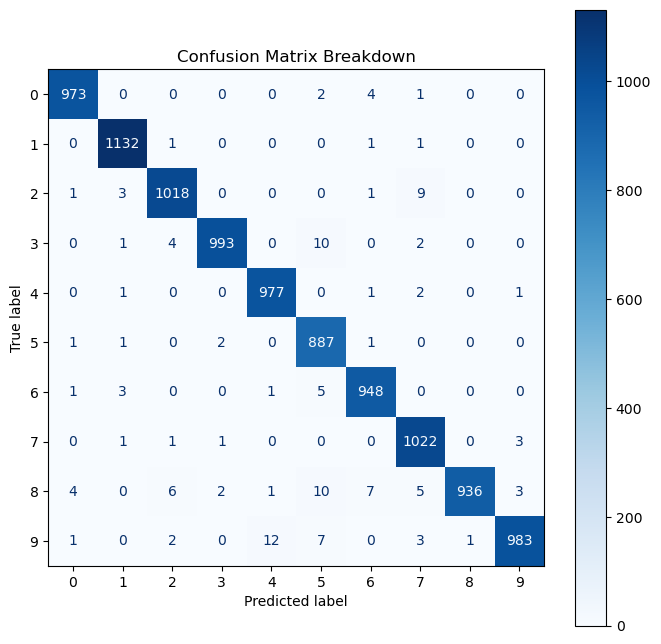

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title('Confusion Matrix Breakdown')
plt.show()